In [ ]:
import pandas as pd
import numpy as np
import re
import warnings
import joblib

warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
from google.colab import files

uploaded = files.upload()

df = pd.read_csv("Electric_Vehicle_Population_Data.csv")

print("Dataset Loaded Successfully!")
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")

Saving Electric_Vehicle_Population_Data.csv to Electric_Vehicle_Population_Data.csv
Dataset Loaded Successfully!
Rows    : 270,262
Columns : 16


In [ ]:
df_clean = df.copy()

print("Working copy created successfully.")

Working copy created successfully.


##Standardize Columns

In [ ]:
df_clean.columns = (
    df_clean.columns
        .str.strip()
        .str.replace(" ", "_")
        .str.replace("(", "", regex=False)
        .str.replace(")", "", regex=False)
        .str.replace("/", "_")
)

print(df_clean.columns.tolist())

['VIN_1-10', 'County', 'City', 'State', 'Postal_Code', 'Model_Year', 'Make', 'Model', 'Electric_Vehicle_Type', 'Clean_Alternative_Fuel_Vehicle_CAFV_Eligibility', 'Electric_Range', 'Legislative_District', 'DOL_Vehicle_ID', 'Vehicle_Location', 'Electric_Utility', '2020_Census_Tract']


In [ ]:
text_columns = [
    "County",
    "City",
    "State",
    "Make",
    "Model",
    "Electric_Vehicle_Type",
    "Clean_Alternative_Fuel_Vehicle_CAFV_Eligibility",
    "Electric_Utility"
]

for col in text_columns:
    df_clean[col] = (
        df_clean[col]
        .astype("string")
        .str.strip()
        .str.upper()
    )

print("Text columns standardized.")

Text columns standardized.


##Missing Value Treatment

In [ ]:
missing = (
    df_clean.isnull()
    .sum()
    .sort_values(ascending=False)
)

print("Columns with missing values:")
print(missing[missing > 0])

Columns with missing values:
Legislative_District    649
Vehicle_Location         88
County                   10
City                     10
2020_Census_Tract        10
Electric_Utility         10
Postal_Code              10
Electric_Range            5
dtype: int64


In [ ]:
df_clean["County"] = df_clean["County"].fillna("Unknown")
df_clean["City"] = df_clean["City"].fillna("Unknown")
df_clean["Electric_Utility"] = df_clean["Electric_Utility"].fillna("Unknown")
df_clean["Legislative_District"] = df_clean["Legislative_District"].fillna("Unknown")

df_clean["Postal_Code"] = df_clean["Postal_Code"].fillna(
    df_clean["Postal_Code"].mode()[0]
)

df_clean["2020_Census_Tract"] = df_clean["2020_Census_Tract"].fillna(
    df_clean["2020_Census_Tract"].mode()[0]
)

print("Missing values handled.")

Missing values handled.


##Electric Range Preprocessing

In [ ]:
zero_range = (df_clean["Electric_Range"] == 0).sum()
missing_range = df_clean["Electric_Range"].isna().sum()

print(f"Zero Electric Range Values : {zero_range:,}")
print(f"Missing Electric Range Values : {missing_range}")
print(f"Percentage of Zero Range : {(zero_range / len(df_clean)) * 100:.2f}%")

Zero Electric Range Values : 169,872
Missing Electric Range Values : 5
Percentage of Zero Range : 62.85%


In [ ]:
df_clean["Electric_Range_Available"] = np.where(
    df_clean["Electric_Range"] > 0,
    1,
    0
)

df_clean["Electric_Range"] = df_clean["Electric_Range"].fillna(0)

print(df_clean["Electric_Range_Available"].value_counts())

Electric_Range_Available
0    169877
1    100385
Name: count, dtype: int64


In [ ]:
# Fill Missing Electric Range Values
df_clean["Electric_Range"] = df_clean["Electric_Range"].fillna(0)

print("Remaining Missing Values:",
      df_clean["Electric_Range"].isna().sum())

Remaining Missing Values: 0


**Electric Range Preprocessing**

Exploratory Data Analysis revealed that **62.85%** of vehicles have an electric range recorded as **0 miles**, while only **5 records** contained missing values.

Instead of replacing all zero values, an **Electric_Range_Available** indicator was created to distinguish vehicles with reported electric range from those without available information.

The five missing electric range values were replaced with **0**, maintaining consistency with the dataset and preserving the interpretation that electric range information is unavailable for those records.

In [ ]:
def range_bucket(x):
    if x == 0:
        return "No Range"
    elif x <= 50:
        return "Short Range"
    elif x <= 150:
        return "Medium Range"
    else:
        return "Long Range"


df_clean["Electric_Range_Bucket"] = (
    df_clean["Electric_Range"].apply(range_bucket)
)

print(df_clean["Electric_Range_Bucket"].value_counts())

Electric_Range_Bucket
No Range        169877
Short Range      50183
Long Range       33898
Medium Range     16304
Name: count, dtype: int64


**Electric Range Bucketing**

To improve interpretability and support downstream analysis, the continuous **Electric Range** feature was grouped into four categories:

- **No Range:** 0 miles [Vehicles with unavailable or zero recorded electric range]
- **Short Range:** 1–50 miles [Mostly short-range EVs and many PHEVs]
- **Medium Range:** 51–150 miles [Mid-range electric vehicles]
- **Long Range:** Above 150 miles [Modern long-range BEVs]

### Business Insight

The engineered electric range buckets show that the majority of vehicles (**169,877**) fall into the **No Range** category, reflecting the large number of records with unavailable or zero electric range identified during EDA.

Among vehicles with reported ranges, **Short Range** vehicles are the most common, followed by **Long Range** and **Medium Range** vehicles. These engineered categories simplify analysis, improve interpretability, and provide meaningful categorical features for downstream modeling.

##CAFV Eligibility Processing

In [ ]:
df_clean[
    "Clean_Alternative_Fuel_Vehicle_CAFV_Eligibility"
] = (
    df_clean[
        "Clean_Alternative_Fuel_Vehicle_CAFV_Eligibility"
    ].replace({
        "CLEAN ALTERNATIVE FUEL VEHICLE ELIGIBLE": "Eligible",
        "NOT ELIGIBLE DUE TO LOW BATTERY RANGE": "Not Eligible",
        "ELIGIBILITY UNKNOWN AS BATTERY RANGE HAS NOT BEEN RESEARCHED": "Unknown"
    })
)

print(
    df_clean[
        "Clean_Alternative_Fuel_Vehicle_CAFV_Eligibility"
    ].value_counts()
)

Clean_Alternative_Fuel_Vehicle_CAFV_Eligibility
Unknown         169872
Eligible         76360
Not Eligible     24030
Name: count, dtype: Int64


In [ ]:
df_clean["CAFV_Status"] = (
    df_clean[
        "Clean_Alternative_Fuel_Vehicle_CAFV_Eligibility"
    ]
)

print(df_clean["CAFV_Status"].value_counts())

CAFV_Status
Unknown         169872
Eligible         76360
Not Eligible     24030
Name: count, dtype: Int64


**CAFV Eligibility Processing**

The original CAFV eligibility values were long descriptive strings, making them difficult to interpret and use during analysis.

The categories were standardized into three concise labels:

- **Eligible**
- **Not Eligible**
- **Unknown**

The **Unknown** category was retained because exploratory data analysis showed that these records are strongly associated with unavailable electric range information rather than data entry errors. Preserving this category ensures that potentially valuable information is not lost during preprocessing.

##Parse Vehicle Location

In [ ]:
df_clean[["Longitude", "Latitude"]] = (
    df_clean["Vehicle_Location"]
    .str.extract(r'POINT \(([-\d\.]+)\s+([-\d\.]+)\)')
)

df_clean["Longitude"] = pd.to_numeric(
    df_clean["Longitude"],
    errors="coerce"
)

df_clean["Latitude"] = pd.to_numeric(
    df_clean["Latitude"],
    errors="coerce"
)

In [ ]:
df_clean["Latitude"] = df_clean["Latitude"].fillna(
    df_clean["Latitude"].median()
)

df_clean["Longitude"] = df_clean["Longitude"].fillna(
    df_clean["Longitude"].median()
)

print("Missing Latitude :", df_clean["Latitude"].isna().sum())
print("Missing Longitude:", df_clean["Longitude"].isna().sum())

Missing Latitude : 0
Missing Longitude: 0


**Vehicle Location Processing**

The `Vehicle_Location` column was stored in the `POINT(longitude latitude)` format. The coordinates were extracted into two separate numerical features: **Longitude** and **Latitude**.

These features enable geographic analysis and can be used directly in machine learning models. Missing coordinate values were imputed using the median to retain all records while minimizing the impact on the overall geographic distribution.

##Vehicle Age Feature Engineering

In [ ]:
CURRENT_YEAR = 2026

df_clean["Vehicle_Age"] = (
    CURRENT_YEAR - df_clean["Model_Year"]
)

print(
    df_clean[
        ["Model_Year", "Vehicle_Age"]
    ].head()
)

   Model_Year  Vehicle_Age
0        2020            6
1        2018            8
2        2019            7
3        2026            0
4        2016           10


In [ ]:
display(df_clean["Vehicle_Age"].describe())

print("\nMinimum Vehicle Age :", df_clean["Vehicle_Age"].min())
print("Maximum Vehicle Age :", df_clean["Vehicle_Age"].max())

,Vehicle_Age
count,270262.000000
mean,4.035532
std,3.053960
min,0.000000
25%,2.000000
50%,3.000000
75%,5.000000
max,27.000000



Minimum Vehicle Age : 0
Maximum Vehicle Age : 27


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

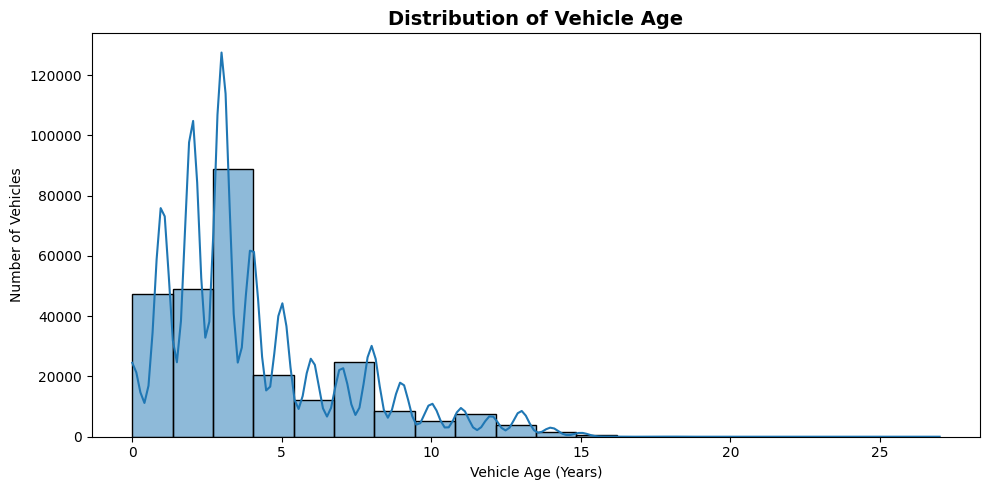

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df_clean,
    x="Vehicle_Age",
    bins=20,
    kde=True
)

plt.title("Distribution of Vehicle Age",
          fontsize=14,
          fontweight="bold")

plt.xlabel("Vehicle Age (Years)")
plt.ylabel("Number of Vehicles")

plt.tight_layout()
plt.show()

**Vehicle Age Feature Engineering**

A new feature, **Vehicle_Age**, was created by subtracting the vehicle's model year from the current year (2026).

This transformation converts the model year into a more informative numerical feature representing the age of each vehicle. Vehicle age is expected to be useful for future analysis and predictive modeling, as it may influence factors such as electric range, eligibility status, and technology adoption.

##Vehicle Vintage
Group vehicles into age categories for easier analysis.

In [ ]:
def vehicle_vintage(age):
    if age <= 2:
        return "New"
    elif age <= 5:
        return "Recent"
    elif age <= 10:
        return "Mid-Age"
    else:
        return "Older"


df_clean["Vehicle_Vintage"] = (
    df_clean["Vehicle_Age"].apply(vehicle_vintage)
)

print(df_clean["Vehicle_Vintage"].value_counts())

Vehicle_Vintage
Recent     109574
New         96471
Mid-Age     50515
Older       13702
Name: count, dtype: int64


**Vehicle Vintage Feature**

The `Vehicle_Vintage` feature groups vehicles into four business-friendly categories based on their age:

- **New:** 0–2 years
- **Recent:** 3–5 years
- **Mid-Age:** 6–10 years
- **Older:** More than 10 years

The distribution shows that most registered EVs fall into the **New** and **Recent** categories, reflecting the rapid growth of electric vehicle adoption in recent years. This feature provides a more interpretable representation of vehicle age and can support trend analysis, customer segmentation, and predictive modeling.

##Premium Brand
Differentiate premium EV manufacturers from mass-market brands.

In [ ]:
premium_brands = [
    "TESLA",
    "BMW",
    "AUDI",
    "MERCEDES-BENZ",
    "PORSCHE",
    "JAGUAR",
    "VOLVO"
]

df_clean["Premium_Brand"] = (
    df_clean["Make"]
    .isin(premium_brands)
    .astype(int)
)

print(df_clean["Premium_Brand"].value_counts())

Premium_Brand
1    140212
0    130050
Name: count, dtype: int64


**Premium Brand Feature**

A binary feature, `Premium_Brand`, was created to distinguish premium EV manufacturers from mass-market brands.

Manufacturers classified as premium include Tesla, BMW, Audi, Mercedes-Benz, Porsche, Jaguar, and Volvo. This feature enables market segmentation and can be useful for analyzing customer preferences and developing predictive models based on manufacturer positioning.

#Is_BEV
Create a binary feature for Battery Electric Vehicles.

In [ ]:
df_clean["Is_BEV"] = np.where(
    df_clean["Electric_Vehicle_Type"]
    == "BATTERY ELECTRIC VEHICLE (BEV)",
    1,
    0
)

print(df_clean["Is_BEV"].value_counts())

Is_BEV
1    215859
0     54403
Name: count, dtype: int64


## Registration Era
Group vehicles based on the evolution of EV adoption.

In [ ]:
def registration_era(year):
    if year <= 2014:
        return "Early Adoption"
    elif year <= 2019:
        return "Growth Phase"
    elif year <= 2022:
        return "Expansion Phase"
    else:
        return "Modern EV Era"


df_clean["Registration_Era"] = (
    df_clean["Model_Year"].apply(registration_era)
)

print(df_clean["Registration_Era"].value_counts())

Registration_Era
Modern EV Era      155795
Expansion Phase     62349
Growth Phase        42846
Early Adoption       9272
Name: count, dtype: int64


**Registration Era Feature**

A new feature, `Registration_Era`, was created by grouping vehicle model years into four business-oriented periods representing different stages of EV market evolution:

- **Early Adoption** (≤ 2014)
- **Growth Phase** (2015–2019)
- **Expansion Phase** (2020–2022)
- **Modern EV Era** (2023 onwards)

This feature captures the evolution of electric vehicle adoption over time and provides a higher-level representation than individual model years. It can support trend analysis, customer segmentation, and predictive modeling.

##Range Efficiency
Categorizes vehicles by electric range

In [ ]:
def range_efficiency(x):
    if x == 0:
        return "Unknown"
    elif x < 50:
        return "Low"
    elif x < 200:
        return "Moderate"
    else:
        return "High"


df_clean["Range_Efficiency"] = (
    df_clean["Electric_Range"]
    .apply(range_efficiency)
)

print(df_clean["Range_Efficiency"].value_counts())

Range_Efficiency
Unknown     169877
Low          50182
High         32480
Moderate     17723
Name: count, dtype: int64


In [ ]:
print("Dataset Shape:", df_clean.shape)

print("\nMissing Values:")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

print("\nData Types:")
print(df_clean.dtypes)

Dataset Shape: (270262, 27)

Missing Values:
Vehicle_Location    88
dtype: int64

Data Types:
VIN_1-10                                                   object
County                                             string[python]
City                                               string[python]
State                                              string[python]
Postal_Code                                               float64
Model_Year                                                  int64
Make                                               string[python]
Model                                              string[python]
Electric_Vehicle_Type                              string[python]
Clean_Alternative_Fuel_Vehicle_CAFV_Eligibility    string[python]
Electric_Range                                            float64
Legislative_District                                       object
DOL_Vehicle_ID                                              int64
Vehicle_Location                                

In [ ]:
df_model = df_clean.copy()

print("Model-ready copy created.")

Model-ready copy created.


##Encoding Categorical Variables


In [ ]:
categorical_columns = [
    "County",
    "City",
    "State",
    "Make",
    "Model",
    "Electric_Vehicle_Type",
    "CAFV_Status",
    "Electric_Range_Bucket",
    "Vehicle_Vintage",
    "Registration_Era",
    "Range_Efficiency"
]

for col in categorical_columns:
    df_model[col] = (
        df_model[col]
        .astype("category")
        .cat.codes
    )

print("Categorical variables encoded successfully.")

Categorical variables encoded successfully.


In [ ]:
columns_to_drop = [
    "VIN_1-10",
    "DOL_Vehicle_ID",
    "Vehicle_Location"
]

df_model_final = df_model.drop(
    columns=columns_to_drop
)

print(
    "Final Model Dataset Shape:",
    df_model_final.shape
)

Final Model Dataset Shape: (270262, 24)


In [ ]:
deployment_encoders = {}

deployment_categorical_columns = [
    "County",
    "City",
    "Make",
    "Model",
    "Electric_Vehicle_Type"
]

for col in deployment_categorical_columns:
    categories = (
        df_clean[col]
        .astype("category")
        .cat.categories
        .tolist()
    )

    deployment_encoders[col] = {
        value: code
        for code, value in enumerate(categories)
    }

print("Deployment mappings created successfully.")

for col, mapping in deployment_encoders.items():
    print(f"{col}: {len(mapping)} categories")

Deployment mappings created successfully.
County: 243 categories
City: 864 categories
Make: 47 categories
Model: 183 categories
Electric_Vehicle_Type: 2 categories


In [ ]:
joblib.dump(
    deployment_encoders,
    "categorical_encoders.pkl"
)

print("categorical_encoders.pkl saved successfully.")

categorical_encoders.pkl saved successfully.


In [ ]:
feature_columns = [
    "County",
    "City",
    "Make",
    "Model",
    "Electric_Vehicle_Type",
    "Electric_Range",
    "Longitude",
    "Latitude",
    "Vehicle_Age",
    "Vehicle_Vintage",
    "Premium_Brand",
    "Is_BEV"
]

print("Final Features:")
for i, feature in enumerate(feature_columns, start=1):
    print(i, feature)

Final Features:
1 County
2 City
3 Make
4 Model
5 Electric_Vehicle_Type
6 Electric_Range
7 Longitude
8 Latitude
9 Vehicle_Age
10 Vehicle_Vintage
11 Premium_Brand
12 Is_BEV


In [ ]:
joblib.dump(
    feature_columns,
    "feature_columns.pkl"
)

print("feature_columns.pkl saved successfully.")

feature_columns.pkl saved successfully.


In [ ]:
X = df_model_final[feature_columns]

print("Feature Matrix Shape:", X.shape)
print("\nFeature Columns:")
print(X.columns.tolist())

print("\nMissing Values:")
print(X.isnull().sum())

Feature Matrix Shape: (270262, 12)

Feature Columns:
['County', 'City', 'Make', 'Model', 'Electric_Vehicle_Type', 'Electric_Range', 'Longitude', 'Latitude', 'Vehicle_Age', 'Vehicle_Vintage', 'Premium_Brand', 'Is_BEV']

Missing Values:
County                   0
City                     0
Make                     0
Model                    0
Electric_Vehicle_Type    0
Electric_Range           0
Longitude                0
Latitude                 0
Vehicle_Age              0
Vehicle_Vintage          0
Premium_Brand            0
Is_BEV                   0
dtype: int64


In [ ]:
df_clean.to_csv(
    "ev_cleaned_dataset.csv",
    index=False
)

df_model.to_csv(
    "ev_model_ready_dataset.csv",
    index=False
)

df_model_final.to_csv(
    "ev_final_ml_dataset.csv",
    index=False
)

print("Datasets saved successfully!")

Datasets saved successfully!


In [ ]:
from google.colab import files

files.download("ev_cleaned_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files

files.download("ev_model_ready_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files

files.download("ev_final_ml_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>